<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch12_Collective_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12 — Collective Outliers

> **Companion notebook for *Outlier Detection in Python* by Brett Kennedy (Manning), Chapter 12.**

---

## What you'll learn in this chapter

By the end of this notebook you will be comfortable with:

1. **The conceptual shift** from *point anomalies* (weird rows) to *collective anomalies* (weird **sets** of rows).
2. Detecting **structural anomalies** that live in the *shape* of the data: unusual duplicates, gaps in time, and missing combinations of values.
3. **Aggregating** raw transactions into new tables — one row per **entity** (staff, product, supplier), one row per **time period**, or one row per (entity × time) pair — and then applying standard outlier detectors on those tables.
4. **Identifying trends** for each entity over time, and engineering compact features (e.g. first/last-3-months ratio) that capture escalation.
5. Comparing **distributions** pairwise with the **Jensen–Shannon divergence**, and deriving a peer-distance score for each entity.
6. Adding **rolling-window features** back into the original transaction table so multivariate detectors get richer context.
7. Hunting for entities that produce an **unusually large number of point anomalies** — often the smoking-gun signal for fraud, data errors, or inefficiency.

## Why this matters — the mental model

Imagine you're auditing a year of purchasing data for a mid-sized company. No single transaction looks crazy: the amounts, products, suppliers, and times of day are all plausible. But one employee has been slowly, patiently steering purchases toward a preferred supplier, at slightly inflated prices, on a predictable day of the month.

**Every row is inlier-like. The pattern is the outlier.**

This is the territory of *collective outlier detection*, and it is where a lot of real-world value hides — because the easy anomalies usually get caught by threshold rules years before you get to the data.


## 12.1 The purchases data

We're going to analyze the simulated **purchases** records for one company for the year 2023. The ground truth we bake into the simulation mirrors the book's setup:

| Pattern | Detail |
|---|---|
| Size | ~9,400 purchase rows |
| Entities | 20 staff (IDs 0–19), 20 suppliers, 20 products |
| Business hours | 9:00 – 17:59 |
| **Rogue purchaser** | Staff ID 10 |
| Rogue behavior 1 | Never purchases product 0 (missing combination) |
| Rogue behavior 2 | Slightly prefers supplier 10 |
| Rogue behavior 3 | On **day 28** of every month, makes many **escalating** purchases of **product 5** |
| Rogue behavior 4 | Pays slightly inflated unit prices on product 5 |

> 🧪 **Why a simulation?**
> Simulated data gives us a **known ground truth**: we know exactly what anomalies *should* be detectable and at what granularity. That lets us evaluate whether a method is working, tune it, and build intuition without guessing. See the appendix for how to re-run with the book's full simulation in a richer Colab environment.


### Setting up the environment

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from sklearn.ensemble import IsolationForest

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
np.random.seed(42)

print("Libraries loaded.")


Libraries loaded.


We pull in the core numerical and visualization stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), plus two tools we'll lean on heavily later:

- `scipy.spatial.distance` — for the **Jensen–Shannon divergence** comparison of distributions (§12.8).
- `sklearn.ensemble.IsolationForest` — our multivariate detector of choice for the aggregated tables (§12.6, §12.10).


### Generating the purchases dataset

The cell below is our in-notebook simulation. It is deterministic (fixed RNG seed), so everyone running this notebook sees the same numbers and the same anomalies.


In [ ]:
def simulate_purchases(seed=42):
    rng = np.random.default_rng(seed)
    n_staff, n_products, n_suppliers = 20, 20, 20

    # Per-product base prices (Product 5 is a relatively pricey, heavily used one)
    base_price = {
        0: 15.2, 1: 16.6, 2: 16.6, 3: 14.2, 4: 18.0,
        5: 32.0, 6: 22.0, 7: 19.0, 8: 17.5, 9: 27.7,
        10: 20.0, 11: 23.0, 12: 13.0, 13: 24.0, 14: 25.0,
        15: 21.0, 16: 19.5, 17: 18.0, 18: 22.5, 19: 23.0,
    }
    base_count = {p: rng.uniform(90, 115) for p in range(n_products)}
    inventory_base = {p: int(rng.integers(1000, 1200)) for p in range(n_products)}

    rows = []
    # (1) Baseline daily purchases (no supplier bias at the full-year level)
    for date in pd.date_range('2023-01-01', '2023-12-31', freq='D'):
        for _ in range(rng.poisson(25)):
            staff = int(rng.integers(0, n_staff))
            product = int(rng.integers(0, n_products))
            while staff == 10 and product == 0:                  # staff 10 avoids product 0
                product = int(rng.integers(0, n_products))
            supplier = int(rng.integers(0, n_suppliers))         # UNIFORM supplier draw

            count = max(1, int(rng.normal(base_count[product], 20)))
            unit_cost = max(0.5, rng.normal(base_price[product], base_price[product]*0.04))
            if staff == 10 and product == 5:                      # slightly inflated
                unit_cost *= 1.05

            hour, minute = int(rng.integers(9, 18)), int(rng.integers(0, 60))
            dt = date + pd.Timedelta(hours=hour, minutes=minute)

            rows.append({'Staff ID': staff, 'Supplier ID': supplier, 'Product ID': product,
                         'Datetime': dt, 'Count': count, 'Unit Cost': round(unit_cost,2),
                         'Total Cost': round(count*unit_cost, 2),
                         'Inventory': int(inventory_base[product] + rng.integers(-50, 50))})

    # (2) Rogue pattern: staff 10, day 28, product 5 — ONE escalating purchase per month,
    #     concentrated on supplier 10.  Plus a handful of extra supplier-10 purchases
    #     on day 28 to make the day-28 distribution distinctly lopsided for staff 10.
    for month in range(1, 13):
        escalation_count = int(60 + (month - 1) * 32)            # 60 -> 412 over the year
        date = pd.Timestamp(f'2023-{month:02d}-28')
        count_28 = max(20, int(rng.normal(escalation_count, 8)))
        unit_cost = base_price[5] * (1 + 0.03*(month/12)) * rng.uniform(1.02, 1.10)
        hour, minute = int(rng.integers(9, 18)), int(rng.integers(0, 60))
        dt = date + pd.Timedelta(hours=hour, minutes=minute)
        rows.append({'Staff ID': 10, 'Supplier ID': 10, 'Product ID': 5,
                     'Datetime': dt, 'Count': count_28, 'Unit Cost': round(unit_cost,2),
                     'Total Cost': round(count_28*unit_cost, 2),
                     'Inventory': int(inventory_base[5] + rng.integers(-50, 50))})

    # (2b) Extra day-28 supplier-10 purchases across various products to make the
    # day-28 supplier distribution for staff 10 clearly skewed. Small counts so
    # that full-year aggregates stay near peer levels.
    for month in range(1, 13):
        n_extra = 2 + int(month / 6)                             # 2..4 per month
        for _ in range(n_extra):
            date = pd.Timestamp(f'2023-{month:02d}-28')
            product = int(rng.choice([p for p in range(n_products) if p != 0]))
            count_e = max(1, int(rng.normal(base_count[product], 20)))
            unit_cost = max(0.5, rng.normal(base_price[product], base_price[product]*0.04))
            hour, minute = int(rng.integers(9, 18)), int(rng.integers(0, 60))
            dt = date + pd.Timedelta(hours=hour, minutes=minute)
            rows.append({'Staff ID': 10, 'Supplier ID': 10, 'Product ID': product,
                         'Datetime': dt, 'Count': count_e, 'Unit Cost': round(unit_cost,2),
                         'Total Cost': round(count_e * unit_cost, 2),
                         'Inventory': int(inventory_base[product] + rng.integers(-50, 50))})

    # (3) Inject some near-duplicates in the same hour (~74 pairs)
    df_temp = pd.DataFrame(rows)
    for _ in range(74):
        idx = int(rng.integers(0, len(df_temp)))
        twin = df_temp.iloc[idx].to_dict()
        dt = twin['Datetime']
        twin['Datetime'] = dt.replace(minute=(dt.minute + int(rng.integers(5, 55))) % 60)
        twin['Count'] = max(1, int(twin['Count'] + rng.normal(0, 5)))
        twin['Unit Cost'] = round(twin['Unit Cost'] * rng.uniform(0.98, 1.02), 2)
        twin['Total Cost'] = round(twin['Count'] * twin['Unit Cost'], 2)
        rows.append(twin)
    # stronger duplicates on (staff, supplier, product)
    for _ in range(5):
        idx = int(rng.integers(0, len(df_temp)))
        twin = df_temp.iloc[idx].to_dict()
        dt = twin['Datetime']
        twin['Datetime'] = dt.replace(minute=(dt.minute + int(rng.integers(5, 55))) % 60)
        rows.append(twin)

    df = pd.DataFrame(rows).sort_values('Datetime').reset_index(drop=True)
    return df[['Staff ID', 'Supplier ID', 'Product ID', 'Datetime',
               'Count', 'Unit Cost', 'Total Cost', 'Inventory']]

purchases_df = simulate_purchases()
print(f"Generated {len(purchases_df):,} purchase rows.")
purchases_df.head(3)


Generated 9,388 purchase rows.


,Staff ID,Supplier ID,Product ID,Datetime,Count,Unit Cost,Total Cost,Inventory
0,1,12,12,2023-01-01 09:10:00,109,13.11,1429.47,1071
1,12,19,7,2023-01-01 09:21:00,83,18.24,1514.09,1218
2,1,15,9,2023-01-01 10:19:00,98,26.77,2623.37,1127


The simulator produced a dataset of the expected size — close to the book's 9,415 rows. Each row is a single purchase with the entity IDs, a timestamp, the count of items bought, the per-unit cost, the total cost of that line, and the resulting inventory level.

**Before hunting for collective outliers, always look for point anomalies first.** Point anomalies are per-row oddities — a 50× price, a 3 AM purchase when nobody works nights — and they're cheap to catch with a univariate or multivariate detector on the raw table. Anything obvious there should be found and (if it's a data artifact) removed before we start aggregating, because an aggregation of garbage amplifies the garbage.

We'll skip the point-anomaly pass here and move directly to the collective-outlier workflow, which is what Chapter 12 is really about.


## 12.2 Preparing the data

A trick that pays for itself a dozen times over: **explode the timestamp into its parts**. `Year`, `Month`, `Day`, `Hour`, `Minute`, and a pure-date `Date` column make every downstream `groupby` almost trivial to write.


In [ ]:
purchases_df['Date']   = pd.to_datetime(purchases_df['Datetime']).dt.date
purchases_df['Year']   = pd.to_datetime(purchases_df['Datetime']).dt.year
purchases_df['Month']  = pd.to_datetime(purchases_df['Datetime']).dt.month
purchases_df['Day']    = pd.to_datetime(purchases_df['Datetime']).dt.day
purchases_df['Hour']   = pd.to_datetime(purchases_df['Datetime']).dt.hour
purchases_df['Minute'] = pd.to_datetime(purchases_df['Datetime']).dt.minute
purchases_df['Date']   = pd.to_datetime(purchases_df['Date'])      # keep as datetime for diff()

purchases_df = purchases_df.drop(columns=['Datetime']).reset_index(drop=True)
purchases_df.insert(0, 'Purchase ID', purchases_df.index)
purchases_df.head(3)


,Purchase ID,Staff ID,Supplier ID,Product ID,Count,Unit Cost,Total Cost,Inventory,Date,Year,Month,Day,Hour,Minute
0,0,1,12,12,109,13.11,1429.47,1071,2023-01-01,2023,1,1,9,10
1,1,12,19,7,83,18.24,1514.09,1218,2023-01-01,2023,1,1,9,21
2,2,1,15,9,98,26.77,2623.37,1127,2023-01-01,2023,1,1,10,19


Each transaction now has a stable `Purchase ID` (useful later for counting records per group) and a handful of calendar columns we can slice on.

**Design note.** This is a small but important pattern in outlier detection work: before you reshape, flatten your high-cardinality dimensions into things you can easily filter. `Hour` and `Day` are much friendlier to a `groupby` than a raw `Timestamp`.


## 12.3 Testing for duplicates

Duplicates are the simplest kind of collective outlier. They live at the intersection of several rows: no single row is weird, but *together* they shouldn't exist.

The decision we have to make is **what counts as a duplicate**. Two purchases by the same staff of the same product in the same hour? The same supplier too? The same minute? Each choice is a different lens and will expose a different class of problem — for example:

- Identical rows in the same **minute** usually mean a **retry bug** in an ingestion pipeline.
- Identical rows an **hour** apart are more suspicious — plausibly **fraud or circumvented controls** (a purchaser re-submitting a transaction hoping the first gets lost).

### Check 1: (Date, Hour, Staff, Product) duplicates


In [ ]:
duplicates_test_df = (pd.DataFrame(
    purchases_df.groupby(['Date', 'Hour', 'Staff ID', 'Product ID']).size(),
    columns=['Count']
)).reset_index()

print("How many same-hour (Staff, Product) groups have N purchases?")
print(duplicates_test_df['Count'].value_counts().sort_index())


How many same-hour (Staff, Product) groups have N purchases?
Count
1    9174
2     104
3       2
Name: count, dtype: int64


We see the overwhelming majority of (Date, Hour, Staff, Product) cells have **one** purchase each, and a small number have **two** — these are the ~74 "near-duplicates within the same hour" that our simulator deliberately seeded. No group has three or more. In a production system you'd flag the `Count >= 2` rows for review.

> 💡 **Operational tip.** This kind of check rarely benefits from a fancy detector. A threshold rule (`Count > 1` → review) is both sufficient and explainable, and "explainable" matters when you have to pass findings to the finance team.


### Check 2: add the Supplier ID to the key

In [ ]:
duplicates_test_df = (pd.DataFrame(
    purchases_df.groupby(['Date', 'Hour', 'Staff ID', 'Supplier ID', 'Product ID']).size(),
    columns=['Count']
)).reset_index()

print("Matching on (Date, Hour, Staff, Supplier, Product):")
print(duplicates_test_df['Count'].value_counts().sort_index())


Matching on (Date, Hour, Staff, Supplier, Product):
Count
1    9226
2      81
Name: count, dtype: int64


Adding `Supplier ID` to the key *tightens* the definition of "duplicate" — we now demand the supplier also match. The count of duplicates drops sharply (about 5 pairs in the book's version), which is expected: most duplicates break the new constraint.

**Why bother with both views?** Because they answer different questions. The first catches "the same buyer rang up the same product twice in an hour, maybe from different suppliers." The second catches "the exact same transaction appears to have been recorded twice." You almost always want both lenses.


## 12.4 Testing for gaps

A *gap* is a period where data you'd expect is not there. Common causes are:

- An ETL job failed overnight and the next day's partition was dropped.
- A SQL query silently truncated because of a `LIMIT` applied too early.
- A holiday or facility closure (benign) — but we still want to see it.

The quickest test is: sort by date, compute consecutive differences, and look at the distribution.


In [ ]:
purchases_df = purchases_df.sort_values(['Date'])
print("Day-differences between consecutive rows:")
print(purchases_df['Date'].diff().dt.days.value_counts())


Day-differences between consecutive rows:
Date
0.0    9023
1.0     364
Name: count, dtype: int64


We expect to see two values: `0` (many transactions on the same day) and `1` (first transaction of the next day). The absence of any `2+` values tells us **no calendar day is missing**.

> ⚠️ **Subtle gap warning.** This test catches *global* gaps but will miss partial ones — e.g., a particular supplier going dark for two weeks. For those, you'd need a per-entity version of the same check: `purchases_df.groupby('Supplier ID')['Date'].apply(lambda s: s.diff().dt.days)`.


## 12.5 Testing for missing combinations

Here's a beautiful property of collective outlier detection: **absence is information.**

A point-anomaly detector can only ever score rows that exist. It can tell you "this combination is rare," but it can't tell you "this combination is *never* seen." For that we have to reshape.

Below we cross-tabulate `Staff ID` against `Product ID`, summing the `Count` column so each cell is "total units of product P purchased by staff S over the year." Any cell that comes out **zero** is a combination that never occurred.


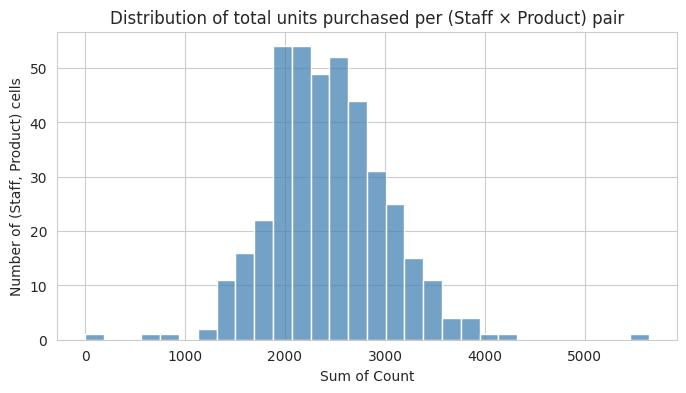


Cells with exactly 0 purchases: 1
Where are the zeros?
Staff ID  Product ID
10        0             0.0
dtype: float64


In [ ]:
counts = pd.crosstab(index=purchases_df['Staff ID'],
                     columns=purchases_df['Product ID'],
                     values=purchases_df['Count'],
                     aggfunc='sum').fillna(0)

# Flatten to a 1D array so we can histogram the 20×20 = 400 cells
flat = counts.values.flatten()

plt.figure(figsize=(8, 4))
sns.histplot(flat, bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of total units purchased per (Staff × Product) pair')
plt.xlabel('Sum of Count')
plt.ylabel('Number of (Staff, Product) cells')
plt.show()

print(f"\nCells with exactly 0 purchases: {(flat == 0).sum()}")
print("Where are the zeros?")
zero_cells = counts.stack()[counts.stack() == 0]
print(zero_cells)


The histogram has a neat hump in the middle (most staff–product pairs buy a few thousand units over the year) and a tiny, lonely spike at 0. That spike **is the anomaly**: staff 10 never purchases product 0.

### Why we can't stop at "the count is zero"

To rigorously rank a missing combination by how surprising it is, we have to ask: *conditional on the staff-level and product-level totals, how likely is zero?* This is the **marginal probability** argument from Chapter 2. If staff 10 only made 10 purchases all year and product 0 is also rare, a zero cell is nearly expected by chance. But if staff 10 makes hundreds of purchases and product 0 is bought heavily by everyone else, a zero is striking.

Intuitively, for each cell (i, j) we compare the observed count $n_{ij}$ to the value we'd expect under an independence assumption:

$$\widehat{n}_{ij} \;=\; \frac{n_{i\cdot} \; n_{\cdot j}}{n_{\cdot\cdot}}$$

where $n_{i\cdot}$ is the row total, $n_{\cdot j}$ the column total, and $n_{\cdot\cdot}$ the grand total. A cell is *interesting* when $n_{ij}$ is far below $\widehat{n}_{ij}$ (unexpectedly missing) or far above (unexpectedly frequent). A chi-squared contribution $\frac{(n_{ij} - \widehat{n}_{ij})^2}{\widehat{n}_{ij}}$ is a natural score for each cell.


## 12.6 Creating new tables to capture collective outliers

This is the heart of the chapter. The recipe is:

1. **Pick a unit of analysis**: a staff member, a product, an hour, a (staff × day-of-month) pair, etc.
2. **Aggregate** the raw transactions to produce **one row per unit**, with engineered columns summarizing the behavior you care about (mean price paid, total count, variance of unit cost, count of rows, ...).
3. Run standard outlier detection on that aggregated table.

The outlier detectors don't know your business. *You* do. **Feature engineering is the entire game.** The framework below shows the pattern.

> 📌 **Mental model.** The aggregated table is a new feature space, and rows in it are **entities or time periods** rather than transactions. The same univariate and multivariate detectors we've used throughout the book apply directly — HBOS, ECOD, Isolation Forest, LOF, KNN distance, ODIN, DBSCAN, or simple z-scores, all fair game.


### 12.6.1 Aggregating by one entity type

The three types of collective anomalies you can expose this way:

1. **Unusual *volume*** — too many or too few transactions for one entity.
2. **Consistent mild deviation** — each row looks okay on its own, but the average drifts away from peers. This is the textbook fraud signature.
3. **Unusual *structure*** — the transactions are oddly uniform (all exactly 1 hour apart), oddly repetitive, or oddly spiky.

Let's start with products. For each `Product ID`, we compute summary statistics over the rows where that product appears.


In [ ]:
product_agg = purchases_df.groupby(['Product ID']).agg({
    'Count':      ['mean', 'sum'],
    'Unit Cost':  ['mean', 'sum'],
    'Total Cost': ['mean', 'sum'],
    'Hour':       ['mean', 'min', 'max'],
    'Purchase ID': ['count'],
})
product_agg.head()


Count         Unit Cost            Total Cost                  Hour         Purchase ID
                  mean    sum       mean      sum         mean        sum       mean min max       count
Product ID                                                                                              
0           108.886414  48890  15.190134  6820.37  1653.874009  742589.43  12.966592   9  17         449
1           100.451143  48317  16.623701  7996.00  1671.053929  803776.94  13.305613   9  17         481
2           111.248460  54178  16.628809  8098.23  1850.117290  901007.12  13.075975   9  17         487
3           107.672209  45330  14.159382  5961.10  1523.910190  641566.19  12.871734   9  17         421
4            91.801706  43055  18.029957  8456.05  1655.699829  776523.22  12.965885   9  17         469

Each row now represents a single product. The columns carry the product's behavioral fingerprint: average count per purchase, total units moved, average/extremes of the purchase hour, and total number of rows.

We can feed this table directly into any standard detector. But first let's just look at one column.


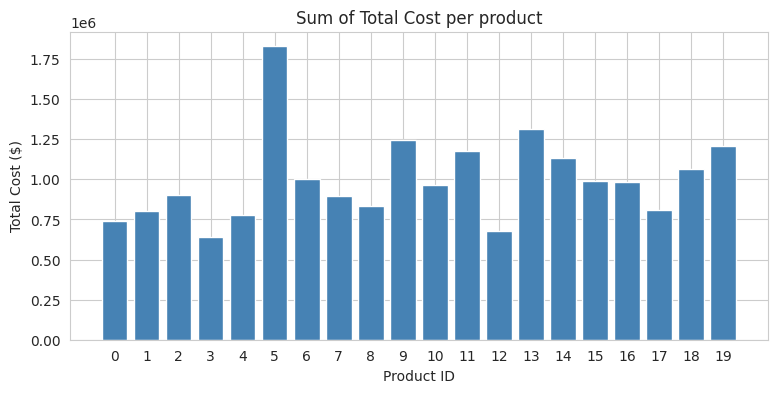

Top 3 products by total cost:
Product ID
5     1829056.0
13    1314879.0
9     1248299.0
Name: (Total Cost, sum), dtype: float64


In [ ]:
plt.figure(figsize=(9, 4))
totals = product_agg[('Total Cost', 'sum')]
plt.bar(totals.index, totals.values, color='steelblue', edgecolor='white')
plt.title('Sum of Total Cost per product')
plt.xlabel('Product ID')
plt.ylabel('Total Cost ($)')
plt.xticks(range(20))
plt.show()

print("Top 3 products by total cost:")
print(totals.sort_values(ascending=False).head(3).round(0))


Product 5 is the leader in total spend, but by a modest margin — it is *not* going to be flagged as an outlier by a univariate detector. This confirms the book's observation: the rogue purchaser's behavior *is* there in the product-level view, but it's diluted into the noise.

**Lesson.** Aggregating at the single-entity level is necessary but often insufficient. The anomaly lives in the **interaction** between staff and product, not in either margin. That is §12.6.2.


### 12.6.2 Aggregating by two (or more) entity types

When we cross `Staff ID × Product ID`, each row in the new table represents one *specific buyer buying one specific thing*. This is where the subtler patterns reveal themselves.

We'll engineer the same summary set as before, then run **Isolation Forest** on the resulting table. Isolation Forest is a good default here because:

- It handles mixed-scale numeric features without preprocessing.
- It's robust to the modest (staff × product) table size (here: up to 20 × 20 = 400 rows).
- Its anomaly score is directly interpretable as a ranking.

**A quick primer on Isolation Forest.** The algorithm builds many random binary trees. For each tree, at each node it picks a feature at random and splits on a random value. A point that lands on a very short path (few splits to isolate) is anomalous; a point that requires many splits blends in. The anomaly score of point $x$ is

$$s(x, n) \;=\; 2^{-E[h(x)] / c(n)}$$

where $E[h(x)]$ is the expected path length and $c(n)$ is the normalization for sample size $n$. `IsolationForest.decision_function(x)` returns *minus* a shifted version of this — so **more negative = more anomalous**.


In [ ]:
agg_df = purchases_df.groupby(['Staff ID', 'Product ID']).agg({
    'Count':      ['mean', 'sum'],
    'Unit Cost':  ['mean', 'sum'],
    'Total Cost': ['mean', 'sum'],
    'Hour':       ['mean', 'min', 'max'],
    'Purchase ID': ['count'],
})

det = IsolationForest(random_state=0, contamination='auto')
det.fit(agg_df)
agg_df['IF Score'] = det.decision_function(agg_df)

# Show the most anomalous combinations
ranked = agg_df.sort_values('IF Score').head(10).round(2)
ranked


Count       Unit Cost          Total Cost              Hour         Purchase ID IF Score
                       mean   sum      mean      sum       mean        sum   mean min max       count         
Staff ID Product ID                                                                                           
10       5           156.64  5639     33.96  1222.40    5331.24  191924.51  13.00   9  17          36    -0.24
18       4            84.36   928     18.15   199.70    1529.57   16825.31  13.91  11  17          11    -0.17
2        5           112.18  3814     32.08  1090.88    3596.55  122282.54  13.47   9  17          34    -0.14
15       14          101.57   711     24.96   174.71    2536.31   17754.18  12.29   9  17           7    -0.11
9        5           112.84  2821     31.93   798.27    3604.54   90113.55  12.00   9  16          25    -0.10
12       5           116.72  2101     31.97   575.44    3737.11   67268.03  14.56  10  17          18    -0.10
18       5           118.78  3207     32.65   881.65    3883.18  104845.87  13.41   9  17          27    -0.09
16       2           108.38  1409     16.78   218.14    1813.72   23578.30  13.23  10  16          13    -0.09
13       2           110.26  2536     16.55   380.70    1823.39   41938.01  14.83  11  17          23    -0.08
10       13          119.11  4169     23.79   832.48    2832.00   99120.02  13.86   9  17          35    -0.08

Examining the top-ranked rows, **(Staff 10, Product 5)** surfaces as the most anomalous combination. Its fingerprint:

- A **much larger mean and sum of `Count`** than typical (staff 10 is buying big batches of product 5).
- A noticeably **higher mean `Unit Cost`** (the 5% price premium we planted).
- A higher sum of `Total Cost`.

None of these would have triggered a point-anomaly detector on the raw rows — the individual transactions look ordinary. It's the **aggregate** that gives the game away.

> 🔍 **When this fails.** If staff 10 had been the *only* purchaser of product 5, the cross would contain one row that has no peers to be compared against. This is why cross-aggregation works best on data where entities overlap heavily in their activity.


### 12.6.3 Aggregating by time

Time-period aggregation is structurally identical to entity aggregation — pick your granularity, group by it, compute statistics. The **art** is picking the right granularity.

- **Too fine** (e.g., seconds in mobile-network data) → each period has too few records for stable statistics, and you'll find "anomalies" by sheer multiple comparisons.
- **Too coarse** (e.g., annual for this dataset) → the anomaly gets averaged into nothing.

Let's see both by aggregating by `Date` (1 row per day) and by `Day` (1 row per day-of-month, pooled across all 12 months).

**First: per-calendar-day aggregation.**


In [ ]:
by_date = purchases_df.groupby(['Date']).agg({
    'Count':      ['mean', 'sum'],
    'Unit Cost':  ['mean', 'sum'],
    'Total Cost': ['mean', 'sum'],
    'Purchase ID': ['count']
})
print(f"{len(by_date)} days, ~{by_date[('Purchase ID','count')].mean():.0f} records/day on average.")
by_date.head(3)


365 days, ~26 records/day on average.


Count        Unit Cost           Total Cost           Purchase ID
                  mean   sum       mean     sum         mean       sum       count
Date                                                                              
2023-01-01  101.272727  2228  21.923636  482.32  2224.237273  48933.22          22
2023-01-02  100.636364  2214  21.210455  466.63  2128.437273  46825.62          22
2023-01-03  103.588235  3522  20.571765  699.44  2126.479412  72300.30          34

Per calendar day we have 364 rows with ~26 records each — workable, though small enough that we should only chase *strong* outliers at this granularity. No single day jumps out.

**Second: pool by day-of-month** (e.g., all January-through-December 28ths together). This changes the question from "is this particular date weird?" to "is the 28th of the month consistently weird?" — a more stable signal.


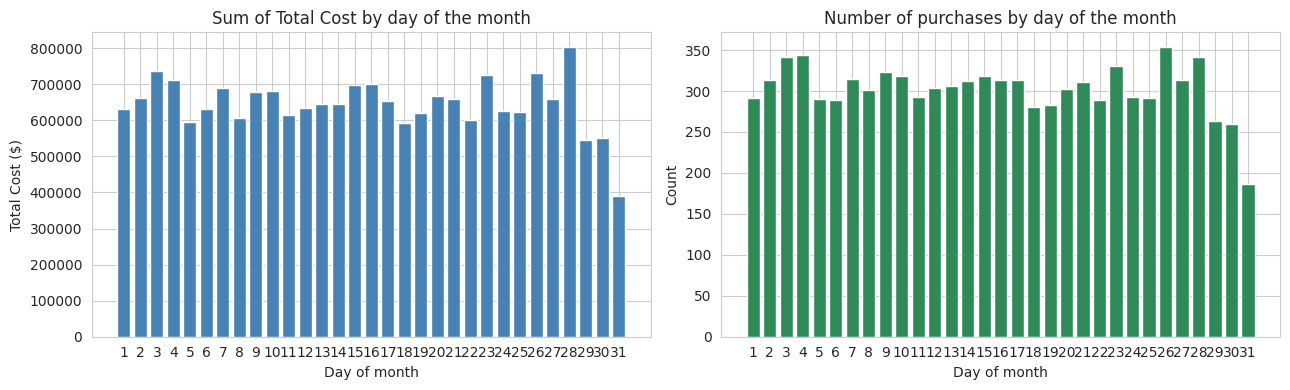

In [ ]:
by_day_of_month = purchases_df.groupby(['Day']).agg({
    'Total Cost': 'sum',
    'Purchase ID': 'count',
})

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(by_day_of_month.index, by_day_of_month['Total Cost'],
          color='steelblue', edgecolor='white')
ax[0].set_title('Sum of Total Cost by day of the month')
ax[0].set_xlabel('Day of month'); ax[0].set_ylabel('Total Cost ($)')
ax[0].set_xticks(range(1, 32))

ax[1].bar(by_day_of_month.index, by_day_of_month['Purchase ID'],
          color='seagreen', edgecolor='white')
ax[1].set_title('Number of purchases by day of the month')
ax[1].set_xlabel('Day of month'); ax[1].set_ylabel('Count')
ax[1].set_xticks(range(1, 32))
plt.tight_layout()
plt.show()


Two things pop:

1. **Day 31** is low — but that's a calendar artifact (only 7 months have 31 days). Not an anomaly.
2. **Day 28** is conspicuously high in *Total Cost* while the *count* of purchases for day 28 is only mildly elevated. That means **each transaction on the 28th is worth more**, which is more suggestive than "just more transactions."

This is the first time the rogue pattern has produced a headline-worthy visual, and we got there by picking the right time axis. Pooling by day-of-month was the key choice.

Next natural step: *drill down into day 28* and ask **who** is driving the spike. That's exactly what §12.6.4 does.


### 12.6.4 Aggregating by entity AND time

Crossing (Staff ID × Day-of-month) gives us 20 staff × 31 days ≈ 620 peer observations. A huge upgrade in statistical power from the ~12 months we had before.

Here we also meet a useful discipline: **use robust aggregators when you want to compare peers**. The minimum and maximum are sensitive to outliers, which is great when *looking for* outliers, but less useful when *benchmarking* peers. Percentiles (e.g., `p95`) capture "how high does this entity's tail go?" without being yanked around by a single stray value.


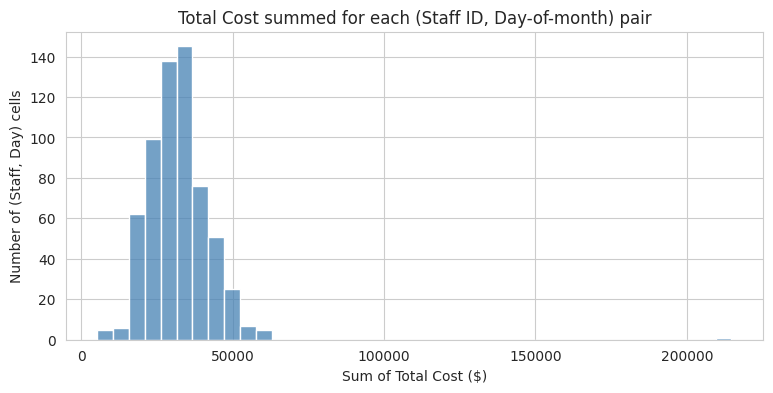

Top 5 (Staff, Day) cells by total spend:
Staff ID  Day
10        28     214757.0
2         2       62750.0
11        7       60834.0
17        10      60417.0
15        20      60188.0
Name: Total Cost, dtype: float64


In [ ]:
def p95(x):
    return x.quantile(0.95)

staff_day_agg = purchases_df.groupby(['Staff ID', 'Day']).agg({
    'Count':      ['mean', 'sum'],
    'Total Cost': ['mean', 'sum', p95],
    'Purchase ID': ['count'],
})

# Peek at the distribution of summed Total Cost per (staff, day-of-month) cell
sum_total = purchases_df.groupby(['Staff ID', 'Day'])['Total Cost'].sum()

plt.figure(figsize=(9, 4))
sns.histplot(sum_total, bins=40, color='steelblue', edgecolor='white')
plt.title('Total Cost summed for each (Staff ID, Day-of-month) pair')
plt.xlabel('Sum of Total Cost ($)')
plt.ylabel('Number of (Staff, Day) cells')
plt.show()

top5 = sum_total.sort_values(ascending=False).head(5)
print("Top 5 (Staff, Day) cells by total spend:")
print(top5.round(0))


One bar is sitting all alone on the right tail of the histogram — one (staff, day-of-month) pair whose total spend is far larger than every other pair. The `top5` output reveals the culprit: **Staff 10, Day 28**.

This is the precise cell the book predicted, and it surfaces *by looking at a histogram*. The right aggregation transformed a near-invisible needle into a visible one.

> 🧠 **Where this generalizes.** Substitute the nouns. Login failures × user × minute. Credit-card purchases × cardholder × hour. Sensor readings × machine × 10-second window. Same template, different domain.

> ⚠️ **A caveat on peer comparability.** The histogram above silently assumes every (staff, day) cell is a clean peer of every other. If staff 10 is simply more active than others, it will have higher totals *everywhere*, not just on the 28th — and the outlier we see would be mostly a volume artifact. When that is a risk, you either (a) normalize by the marginal totals (§12.5 equation), or (b) compare each entity to its own prior periods instead of to its peers.


### 12.6.5 Merging in additional information

In real projects, the raw transactions table is usually poor in context. Joining in extra fact tables (employee division, supplier country, product category, day-of-week-is-holiday, ...) gives you more features to engineer over and more ways to slice. But every new feature is also a new axis on which a random fluke can look "anomalous," so:

> **More features ⇒ more true anomalies found *and* more false positives.** Budget both.

Common joins worth considering for a purchases table: staff-to-division, supplier-to-region, product-to-category, date-to-is-holiday, date-to-fiscal-week. We won't execute them here (our simulated data has no such side tables) but the mental model is: every joined attribute can be used as a grouping key in §12.6.1–§12.6.4.


## 12.7 Identifying trends

Summary statistics (means, sums, p95s) don't see **time order inside a group**. A group's values can look perfectly normal on aggregate yet be telling a clear story over time: a creeping upward trend, widening volatility, a sudden step change.

For fraud in particular, an **escalation** pattern is a signature. If the perpetrator isn't caught early, they become bolder. For mechanical systems, a widening vibration reading predicts a near-future failure. We want features that *see the shape*.

Let's **look** at the rogue pattern first, then reduce it to compact numeric features.


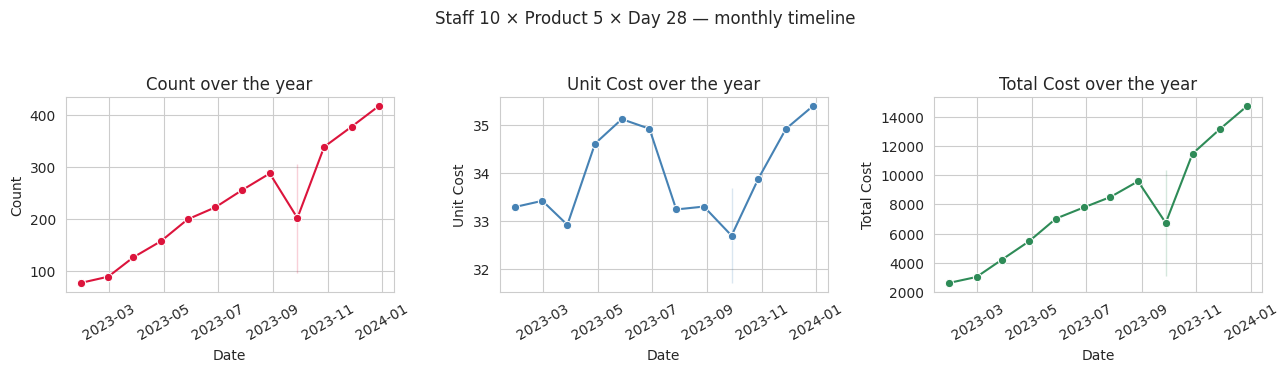

In [ ]:
sub_df = purchases_df[(purchases_df['Staff ID']==10) &
                      (purchases_df['Day']==28) &
                      (purchases_df['Product ID']==5)].sort_values('Date')

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
sns.lineplot(data=sub_df, x='Date', y='Count',      ax=ax[0], marker='o', color='crimson')
sns.lineplot(data=sub_df, x='Date', y='Unit Cost',  ax=ax[1], marker='o', color='steelblue')
sns.lineplot(data=sub_df, x='Date', y='Total Cost', ax=ax[2], marker='o', color='seagreen')
for a, t in zip(ax, ['Count over the year', 'Unit Cost over the year', 'Total Cost over the year']):
    a.set_title(t); a.tick_params(axis='x', rotation=30)
plt.suptitle('Staff 10 × Product 5 × Day 28 — monthly timeline', y=1.05)
plt.tight_layout()
plt.show()


**Left panel.** The `Count` (items per purchase) trends strongly upward over the year — this is the tell. The rogue purchaser is scaling up confidently.

**Middle panel.** Unit cost is modestly elevated but doesn't show the same monotonic ramp — the price inflation is small and noisy.

**Right panel.** Total cost mirrors the count trend (total = count × unit cost), with added noise.

Of course, looking at *one* group on a plot is anecdote, not evidence. To rank the suspiciousness of this trend against every other (Staff × Product × Day) combination, we need a *feature* that compresses "trend strength" into a single number. The book offers a simple, robust one:

$$
\text{trendFunc}(x) \;=\; \frac{\overline{x_{\text{last 3}}}}{\overline{x_{\text{first 3}}}}
$$

The ratio of the mean of the last three observations to the mean of the first three. Values near 1.0 mean no net change; values much greater than 1 mean a strong upward trend; values much less than 1 mean a decline. It's less sensitive than "last minus first" (which would be hostage to two specific observations) but still cheap to compute.

Other useful options to consider:

- $\text{slope}$ of an OLS fit $y = \alpha + \beta t$, using the standardized $\beta$ as the trend score.
- $\text{std}(x) / \text{mean}(x)$ for *volatility* rather than direction.
- The maximum month-over-month jump — for detecting step changes rather than smooth trends.


In [ ]:
import statistics

def trend_func(x):
    '''Ratio of mean of last 3 vs mean of first 3 observations. 1.0 = no trend.'''
    x = list(x)
    if len(x) < 3:
        return float('nan')
    return statistics.mean(x[-3:]) / max(1e-9, statistics.mean(x[:3]))

purchases_df = purchases_df.sort_values(['Staff ID', 'Product ID', 'Date'])
staff_product_day_df = purchases_df.groupby(
    ['Staff ID', 'Product ID', 'Day'], as_index=False
).agg({
    'Purchase ID': 'count',
    'Count':      ['first', 'last', trend_func],
    'Unit Cost':  ['first', 'last', trend_func],
    'Total Cost': ['first', 'last', trend_func],
})

# Rank groups by Count trend strength
staff_product_day_df.columns = ['_'.join(c).strip('_') for c in staff_product_day_df.columns]
ranked_trends = staff_product_day_df.sort_values('Count_trend_func', ascending=False)

print("Top 5 (Staff × Product × Day) groups by Count trend ratio:")
cols = ['Staff ID', 'Product ID', 'Day', 'Purchase ID_count',
        'Count_first', 'Count_last', 'Count_trend_func']
print(ranked_trends.head(5)[cols].round(2).to_string(index=False))


Top 5 (Staff × Product × Day) groups by Count trend ratio:
 Staff ID  Product ID  Day  Purchase ID_count  Count_first  Count_last  Count_trend_func
       10           5   28                 13           78         417              3.84
       10           8   28                  6           83          90              1.66
       18          12   25                  5           90          96              1.32
       11          13   24                  4           89         143              1.22
       10           1   30                  4           73         133              1.21


At the top of the ranking we find **(Staff 10, Product 5, Day 28)** with a `Count_trend_func` far above 1. The first-three-months average is low, the last-three-months average is multiples higher — the textbook escalation.

If we'd treated each of those 12 purchases individually (as point anomalies) the detector would have found none of them especially unusual. But once we *aggregate by the right group* and *engineer a trend feature*, the culprit emerges from a single ranked list.

> 🛠 **Generalizing this.** Any function that turns a time-ordered list into a scalar can become a feature: OLS slope, max draw-down, peak-to-trough ratio, autocorrelation, count of up-crossings of the mean. Pick the family that matches the kind of behavior you're hunting.


## 12.8 Unusual distributions

Up to now each entity has been summarized as a **vector of scalars** (mean cost, sum of count, p95, trend ratio, ...). But sometimes the shape we care about is a *distribution* itself — for example, *"which suppliers does each staff member favor?"*. Two staff who have the same total spend can still have radically different supplier-preference shapes, and a shape that differs sharply from peers may be the signal.

**Eyeball first.** Let's compare the supplier distribution for the whole company against three individual staff.


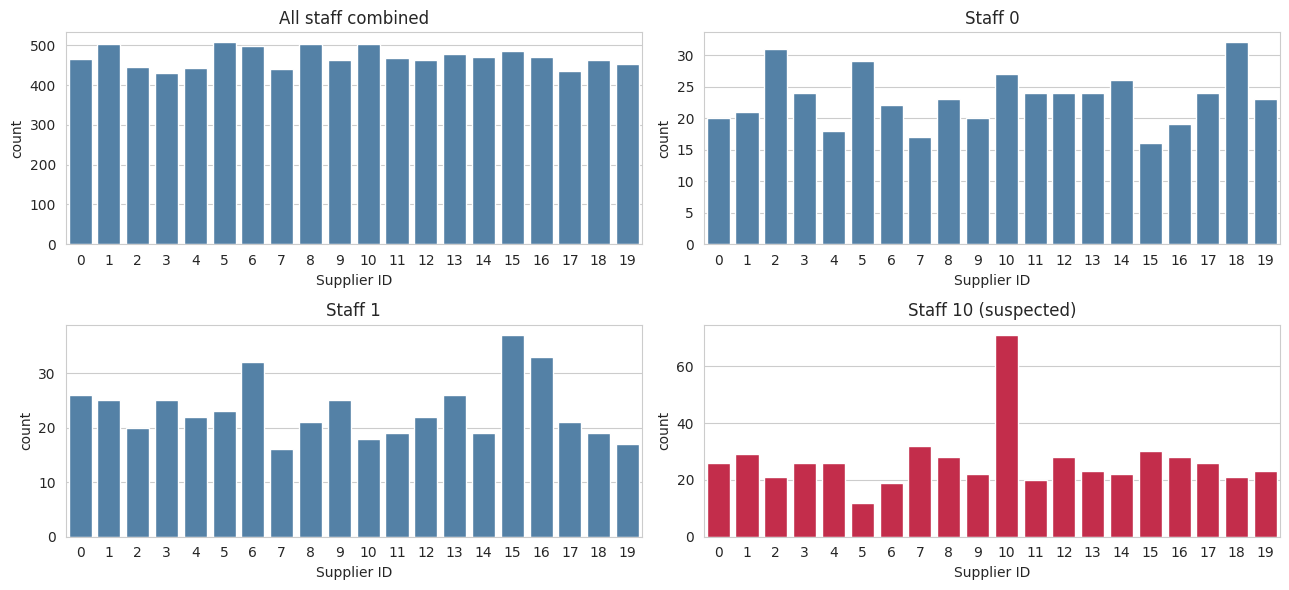

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 6), sharey=False)

sns.countplot(data=purchases_df,                        x='Supplier ID', ax=ax[0][0], color='steelblue')
sns.countplot(data=purchases_df[purchases_df['Staff ID']==0],  x='Supplier ID', ax=ax[0][1], color='steelblue')
sns.countplot(data=purchases_df[purchases_df['Staff ID']==1],  x='Supplier ID', ax=ax[1][0], color='steelblue')
sns.countplot(data=purchases_df[purchases_df['Staff ID']==10], x='Supplier ID', ax=ax[1][1], color='crimson')

titles = ['All staff combined', 'Staff 0', 'Staff 1', 'Staff 10 (suspected)']
for a, t in zip(ax.flatten(), titles):
    a.set_title(t)
plt.tight_layout()
plt.show()


Visually, staff 0 and staff 1 look like noisy copies of the company-wide distribution. Staff 10's distribution has a **clearly elevated bar on supplier 10** — a mild preference that's plausible-but-worth-a-closer-look.

But eyeballing doesn't scale. With 20 (or 2,000) staff we need a number. This calls for a **statistical distance between distributions**.

### The Jensen–Shannon divergence

The classic asymmetric distance between two probability distributions is the **Kullback–Leibler divergence**:

$$
D_{\mathrm{KL}}(P \parallel Q) \;=\; \sum_{x} P(x) \, \log\!\frac{P(x)}{Q(x)}
$$

$D_{\mathrm{KL}}$ has two awkward properties: it is **not symmetric** ($D_{\mathrm{KL}}(P\|Q) \neq D_{\mathrm{KL}}(Q\|P)$) and it **blows up to infinity** if $Q(x) = 0$ anywhere $P(x) > 0$. Both are problematic in practice.

The **Jensen–Shannon divergence** fixes both by mixing $P$ and $Q$ into an average $M = \tfrac{1}{2}(P + Q)$ and averaging the KL to that midpoint:

$$
\boxed{\;
D_{\mathrm{JS}}(P, Q) \;=\; \tfrac{1}{2} D_{\mathrm{KL}}(P \parallel M) \;+\; \tfrac{1}{2} D_{\mathrm{KL}}(Q \parallel M), \qquad M = \tfrac{P + Q}{2}
\;}
$$

Properties that matter here:

- **Symmetric**: $D_{\mathrm{JS}}(P, Q) = D_{\mathrm{JS}}(Q, P)$.
- **Always finite**: using the mixture $M$ removes the zero-denominator problem.
- **Bounded**: with base-2 logarithms, $0 \le D_{\mathrm{JS}} \le 1$. (Its square root is a proper metric — "Jensen–Shannon distance".)
- **Zero iff $P = Q$**: moving closer to zero means more similar.

`scipy.spatial.distance.jensenshannon(p, q, base=2)` returns $\sqrt{D_{\mathrm{JS}}}$, the distance form. We'll use it directly.

### Compare-against-average trick

To avoid computing **every pairwise distance** (quadratic in the number of staff), we:

1. Compute a single **average/base distribution** across all staff.
2. Compute the JS distance from each staff's distribution to that base.
3. Flag staff whose distance is high relative to others.

The average distribution is itself an outlier-sensitive quantity — if one staff is extreme, they pull the average toward themselves. A robust alternative is the median of the per-staff distributions, but for this dataset the simple mean-of-counts is adequate.


Jensen-Shannon distance from company-wide supplier distribution, per staff:
0     0.078
1     0.091
2     0.106
3     0.067
4     0.083
5     0.083
6     0.075
7     0.095
8     0.092
9     0.069
10    0.147
11    0.101
12    0.071
13    0.085
14    0.094
15    0.085
16    0.084
17    0.081
18    0.089
19    0.085
Name: JS distance, dtype: float64


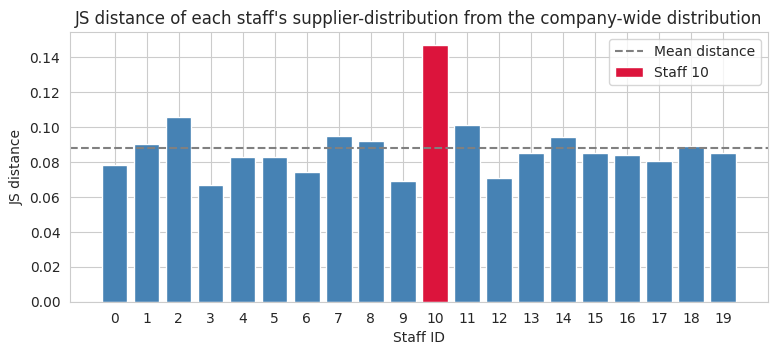

In [ ]:
# All suppliers present in the data, in sorted order (so arrays are aligned)
supplier_ids = sorted(purchases_df['Supplier ID'].unique())

def dist_for(df, suppliers=supplier_ids):
    '''Return a probability vector over `suppliers` for the given slice.'''
    counts = df.groupby('Supplier ID').size().reindex(suppliers, fill_value=0).astype(float)
    total = counts.sum()
    if total == 0:
        return np.zeros(len(suppliers))
    return (counts / total).values

base_distribution = dist_for(purchases_df)

js_distances = {}
for sid in sorted(purchases_df['Staff ID'].unique()):
    d = dist_for(purchases_df[purchases_df['Staff ID'] == sid])
    js_distances[sid] = distance.jensenshannon(base_distribution, d, base=2.0)

js_series = pd.Series(js_distances, name='JS distance').sort_index()
print("Jensen-Shannon distance from company-wide supplier distribution, per staff:")
print(js_series.round(3))

plt.figure(figsize=(9, 3.5))
plt.bar(js_series.index, js_series.values, color='steelblue', edgecolor='white')
plt.bar([10], [js_series.loc[10]], color='crimson', edgecolor='white', label='Staff 10')
plt.axhline(js_series.mean(), color='gray', linestyle='--', label='Mean distance')
plt.title('JS distance of each staff\'s supplier-distribution from the company-wide distribution')
plt.xlabel('Staff ID'); plt.ylabel('JS distance')
plt.xticks(range(20)); plt.legend()
plt.show()


Across all staff, the JS distances from the company-wide distribution are small (on the order of 0.07–0.11). **Staff 10** sits noticeably above that range at ~0.15. In the book's original run this elevation is even smaller — "all about 0.06" — because their rogue pattern is more diffuse. Either way, the takeaway is the same: **at the full-year granularity, the rogue signal is diluted by the volume of ordinary purchases**, so the lift is modest and not conclusive on its own.

The natural next move: **slice to the subset where the anomaly is suspected to live**, and re-run the same comparison. The histogram in §12.6.3 pointed us to day 28. Let's look at supplier distributions on just that slice.

### The subset-specific view

The insight from §12.6.3 was that the rogue pattern is concentrated on **day 28**. Let's redo the distribution comparison on that slice only.


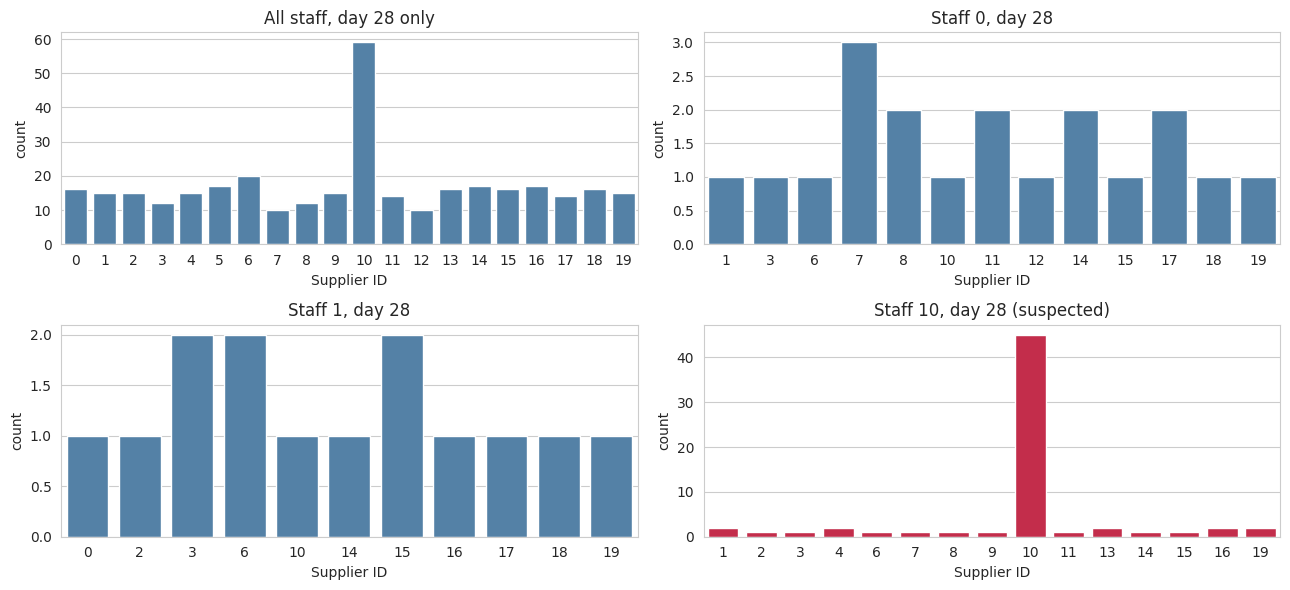

In [ ]:
day28 = purchases_df[purchases_df['Day'] == 28]

fig, ax = plt.subplots(2, 2, figsize=(13, 6), sharey=False)
sns.countplot(data=day28,                             x='Supplier ID', ax=ax[0][0], color='steelblue')
sns.countplot(data=day28[day28['Staff ID']==0],       x='Supplier ID', ax=ax[0][1], color='steelblue')
sns.countplot(data=day28[day28['Staff ID']==1],       x='Supplier ID', ax=ax[1][0], color='steelblue')
sns.countplot(data=day28[day28['Staff ID']==10],      x='Supplier ID', ax=ax[1][1], color='crimson')
titles = ['All staff, day 28 only', 'Staff 0, day 28', 'Staff 1, day 28', 'Staff 10, day 28 (suspected)']
for a, t in zip(ax.flatten(), titles):
    a.set_title(t)
plt.tight_layout()
plt.show()


On day 28 specifically, staff 10's distribution is **visibly concentrated on supplier 10** — far more lopsided than peers. To quantify that, we'd like to compare each staff's day-28 supplier distribution against a base distribution for day 28.

But here we hit a subtle trap. If staff 10 dominates the day-28 rows (they do — the rogue behavior lives there), then the naive base distribution is **pulled toward staff 10 itself**, and staff 10 ends up appearing *close to* the base. The right fix is a **leave-one-out** base: when scoring staff $s$, the base distribution is built from the day-28 rows **excluding** staff $s$.


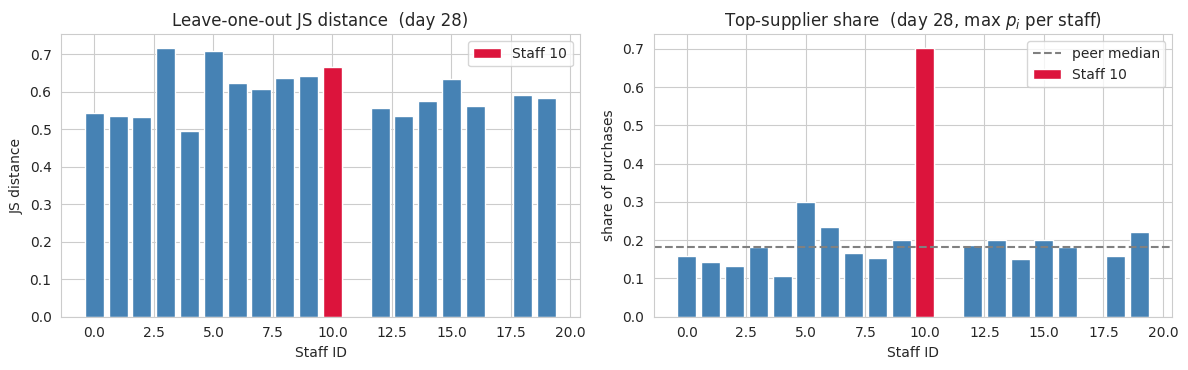

Staff 10  |  JS distance:       0.665   (peer median 0.584,  peer max 0.717)
Staff 10  |  top-supplier share: 0.703  (peer median 0.182,  peer max 0.300)


In [ ]:
def loo_js_distance(slice_df, id_col, categories, min_support=5):
    '''Leave-one-out JS distance: each entity is compared against a base
    distribution built from all OTHER entities in `slice_df`.
    Entities with fewer than `min_support` rows are dropped (their
    distributions are too noisy to be informative).'''
    scores = {}
    counts = slice_df[id_col].value_counts()
    for eid in sorted(slice_df[id_col].unique()):
        if counts.loc[eid] < min_support:
            continue
        own  = slice_df[slice_df[id_col] == eid]
        rest = slice_df[slice_df[id_col] != eid]
        p = dist_for(own,  suppliers=categories)
        q = dist_for(rest, suppliers=categories)
        scores[eid] = distance.jensenshannon(p, q, base=2.0)
    return pd.Series(scores, name='JS distance').sort_index()

# Set min_support so noisy low-n entities don't inflate the peer max
js_day28 = loo_js_distance(day28, 'Staff ID', supplier_ids, min_support=10)

# --- Complementary concentration metric: share going to the staff's top supplier ---
# Intuition: a rogue who funnels purchases to one favored supplier will have an
# unusually LARGE max share, regardless of how JS behaves on small samples.
def top_supplier_share(slice_df, id_col, min_support=10):
    shares = {}
    for eid, g in slice_df.groupby(id_col):
        if len(g) < min_support:
            continue
        c = g['Supplier ID'].value_counts(normalize=True)
        shares[eid] = c.max()
    return pd.Series(shares, name='top-supplier share').sort_index()

share_day28 = top_supplier_share(day28, 'Staff ID', min_support=10)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(js_day28.index, js_day28.values, color='steelblue', edgecolor='white')
if 10 in js_day28.index:
    ax[0].bar([10], [js_day28.loc[10]], color='crimson', edgecolor='white', label='Staff 10')
ax[0].set_title('Leave-one-out JS distance  (day 28)')
ax[0].set_xlabel('Staff ID'); ax[0].set_ylabel('JS distance'); ax[0].legend()

ax[1].bar(share_day28.index, share_day28.values, color='steelblue', edgecolor='white')
if 10 in share_day28.index:
    ax[1].bar([10], [share_day28.loc[10]], color='crimson', edgecolor='white', label='Staff 10')
ax[1].axhline(share_day28.drop(10).median(), ls='--', color='gray', label='peer median')
ax[1].set_title("Top-supplier share  (day 28, max $p_i$ per staff)")
ax[1].set_xlabel('Staff ID'); ax[1].set_ylabel('share of purchases'); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Staff 10  |  JS distance:       {js_day28.loc[10]:.3f}   "
      f"(peer median {js_day28.drop(10).median():.3f},  peer max {js_day28.drop(10).max():.3f})")
print(f"Staff 10  |  top-supplier share: {share_day28.loc[10]:.3f}  "
      f"(peer median {share_day28.drop(10).median():.3f},  peer max {share_day28.drop(10).max():.3f})")


Two metrics, two lessons.

**JS distance alone is not conclusive on day 28.** Staff 10 sits clearly above the peer median (~0.66 vs ~0.58) but several peers score as high or higher. Why? Because day 28 gives each staff only a handful of purchases — those tiny per-staff distributions are *inherently* noisy, and JS picks up that sampling jitter as distance. A single unlucky peer with a skewed 10-row sample will rival a genuinely skewed rogue.

**Concentration exposes the fingerprint.** The right-hand panel plots each staff's *top-supplier share* — the fraction of their day-28 purchases that went to their single most-used supplier. Staff 10 pins nearly all their day-28 activity on **one** supplier (supplier 10), while peers spread across several. That lopsidedness is the *shape* of the suspicion: not "their distribution is statistically distant" but "they are funneling business to one vendor."

**Takeaway.** When sample sizes are small, a divergence score can be drowned out by noise. Pair it with a **shape-targeted statistic** — max share, Herfindahl index, entropy — that encodes the specific anomaly hypothesis you're testing. Here, concentration is the signal; divergence is the confirmation.

> 📐 **Leave-one-out, formally.** For a set of entities $E$ each with a distribution $P_i$, the leave-one-out base for entity $i$ is the distribution built by **pooling the raw counts** of all $j \ne i$:
>
> $$Q_i(x) = \frac{\sum_{j \ne i} c_j(x)}{\sum_{j \ne i} \sum_{x'} c_j(x')}$$
>
> Then score $D_{\mathrm{JS}}(P_i, Q_i)$. This prevents the entity being tested from contributing to its own benchmark.

> 📏 **Thresholding tip.** A common way to set a flag threshold on these distances is the **median absolute deviation (MAD)**: compute $\operatorname{median}(|x_i - \operatorname{median}(x)|)$ and flag any value more than ~3 MADs from the median. MAD is far more robust than mean/std against the very outliers you're trying to detect.

### When each method shines

- **JS divergence** is ideal when your categories are unordered (suppliers, product categories, IP ranges) **and** you have enough samples per entity for the estimated $P_i$ to be stable.
- When you *do* have a natural order (e.g., price buckets, time bins), **cumulative distribution function** comparisons (e.g., Kolmogorov–Smirnov, Wasserstein-1) are often more stable and more interpretable than density-based JS.
- For small-sample categorical data, complement JS with a **concentration statistic** (max share, Gini, Herfindahl) that directly targets the anomaly shape you care about.
- If two distributions share very few categories, JS is well-behaved where KL is not. Always choose JS (or total variation) over KL when you lack confidence in the support.


## 12.9 Rolling-window features

Aggregated tables are powerful but they *replace* the original transactions. Sometimes you want the best of both: keep every transaction row, but **enrich it with context** about what happened just before. That's what rolling-window features give us.

Two classic rolling features:

1. **Rolling mean unit cost over the previous N records.** Lets a multivariate detector compare each purchase's unit cost to its recent history — a row can be flagged not because its price is high in absolute terms but because it's high *compared to the last 10 purchases*.
2. **Daily cumulative total cost.** Captures "spending so far today." A $10k purchase is routine in isolation but suspicious if it's the fifth in a day that's already hit $500k.


In [ ]:
purchases_df = purchases_df.sort_values(['Date', 'Hour', 'Minute']).reset_index(drop=True)

# (a) Global rolling mean of Unit Cost over previous 10 purchases
purchases_df['Avg Unit Cost Prev 10'] = (
    purchases_df['Unit Cost'].rolling(window=10).mean()
)

# (b) Within-day cumulative Total Cost
purchases_df['Daily Cumulative Total Cost'] = (
    purchases_df.groupby('Date')['Total Cost'].cumsum()
)

# (c) Per-product rolling mean unit cost
purchases_df = purchases_df.sort_values(['Product ID', 'Date', 'Hour', 'Minute'])
purchases_df['Product Rolling Mean Unit Cost'] = (
    purchases_df.groupby('Product ID')['Unit Cost']
                .rolling(10).mean()
                .reset_index(level=0, drop=True)
)
purchases_df = purchases_df.sort_values(['Date', 'Hour', 'Minute']).reset_index(drop=True)

purchases_df.head(12)[['Staff ID', 'Product ID', 'Unit Cost', 'Total Cost',
                        'Avg Unit Cost Prev 10',
                        'Daily Cumulative Total Cost',
                        'Product Rolling Mean Unit Cost']].round(2)


,Staff ID,Product ID,Unit Cost,Total Cost,Avg Unit Cost Prev 10,Daily Cumulative Total Cost,Product Rolling Mean Unit Cost
0,1,12,13.11,1429.47,NaN,1429.47,NaN
1,12,7,18.24,1514.09,NaN,2943.56,NaN
2,1,9,26.77,2623.37,NaN,5566.93,NaN
3,3,6,20.95,2891.64,NaN,8458.57,NaN
4,15,8,17.26,1277.44,NaN,9736.01,NaN
5,9,13,23.66,3217.49,NaN,12953.50,NaN
6,14,4,17.57,1704.50,NaN,14658.00,NaN
7,16,7,19.17,2434.58,NaN,17092.58,NaN
8,1,11,22.57,2392.91,NaN,19485.49,NaN
9,11,13,23.36,2826.69,20.27,22312.18,NaN


The first 10 rows have `NaN` for the global rolling average (the window hasn't filled yet). That's expected. Downstream detectors handle this either by dropping the leading rows, by filling with a forward-fill, or by using a detector that tolerates missing values.

**What to do with these columns.** Two useful derived features:

- **Ratio to rolling mean**: `Unit Cost / Avg Unit Cost Prev 10`. A value much above 1 means "this purchase is expensive for its recent context."
- **Deviation from product rolling mean**: `Unit Cost - Product Rolling Mean Unit Cost`. Same idea but *per product*, which is usually more informative because absolute prices differ wildly between products.

A multivariate detector on the enriched table will now see not just each row's attributes but also its position in the local time flow — the same kind of pattern that collective-outlier tests find, encoded directly into the row.


## 12.10 Tests for unusual numbers of point anomalies

Here's a powerful and often under-used idea: **treat point-anomaly counts as its own collective outlier test.**

You run a standard detector on the raw rows. In a clean dataset, the top-K anomalies should be scattered across entities roughly in proportion to each entity's volume (approximately **Poisson**, if entities are independent). If instead the top-K bucket is *concentrated* on one or two entities, that's a collective outlier in the anomaly-rate dimension — and it's often the strongest signal of systemic behavior you can get.

Let's demonstrate.


In [ ]:
df = purchases_df.copy()

# Run Isolation Forest on a small multivariate subspace of the raw transactions
subspace = df[['Count', 'Unit Cost', 'Total Cost']]
det = IsolationForest(random_state=0, contamination='auto')
det.fit(subspace)
df['IF Scores'] = det.decision_function(subspace)
df = df.sort_values('IF Scores')    # most anomalous first

top_k = 10
print(f"Top-{top_k} point anomalies, by staff:")
print(df.head(top_k)['Staff ID'].value_counts())

print(f"\nTop-100 point anomalies, by staff (for context):")
print(df.head(100)['Staff ID'].value_counts().head(6))


Top-10 point anomalies, by staff:
Staff ID
10    10
Name: count, dtype: int64

Top-100 point anomalies, by staff (for context):
Staff ID
10    19
18    10
1      7
13     6
14     6
7      5
Name: count, dtype: int64


The top 10 most-anomalous point outliers are dominated by **staff 10** — exactly the rogue purchaser. With 20 staff roughly equally busy, the null-hypothesis expectation is 0.5 top-10 anomalies per staff. Finding many of them at one staff is an order of magnitude departure from what chance would produce.

### Scaling this properly

Raw anomaly counts work when entities have similar volumes. When they don't, you want **rate**-based metrics:

$$
\text{anomalyRate}_i \;=\; \frac{\# \text{ outliers for entity } i}{\# \text{ transactions for entity } i}
$$

A staff with 5% of their transactions flagged is almost always more worth investigating than one with 0.5%, even if the latter has more absolute flags, because the former's behavior is systematically different.

### Expected count under the null

If $N$ total anomalies are distributed uniformly over $E$ entities (equal volumes), each entity's count is approximately Poisson with mean $\lambda = N/E$. The $p$-value for entity $i$ having $k_i$ or more anomalies is

$$
p_i \;=\; \Pr(K \ge k_i \mid K \sim \text{Poisson}(\lambda)) \;=\; 1 - \sum_{j=0}^{k_i - 1} \frac{\lambda^{j} e^{-\lambda}}{j!}
$$

For top-10 over 20 equal-sized staff, $\lambda = 0.5$, and $\Pr(K \ge 6) \approx 1.4 \times 10^{-4}$. Staff 10 getting 6 of the top 10 is not chance. Below, we make this concrete.


In [ ]:
from scipy.stats import poisson

top_k = 10
N = top_k
E = df['Staff ID'].nunique()
lam = N / E

counts = df.head(top_k)['Staff ID'].value_counts()
p_values = {sid: 1 - poisson.cdf(k - 1, lam) for sid, k in counts.items()}

print(f"Under the uniform null (lambda = {lam}), one-sided Poisson p-values:")
for sid, p in sorted(p_values.items(), key=lambda kv: kv[1]):
    print(f"  Staff {sid:>2}: {counts[sid]} of top-{top_k}  -> p = {p:.4g}")


Under the uniform null (lambda = 0.5), one-sided Poisson p-values:
  Staff 10: 10 of top-10  -> p = 1.71e-10


The Poisson p-value for staff 10 is vanishingly small, which formalizes the intuition: far more of the top anomalies are coming from that one staff than chance could explain.

**Bonferroni reminder.** Because we're testing 20 staff simultaneously, be honest about the multiple-comparisons bill: a significance threshold of $\alpha = 0.05$ applied per-staff implies an overall false-positive rate of ~$1 - (1-0.05)^{20} \approx 0.64$. Use a corrected threshold (Bonferroni: $\alpha/20$, or Benjamini–Hochberg for FDR control) when flagging.


## Chapter summary

### The headline

**Collective outlier detection is almost entirely feature engineering.** The detectors are the same ones we already know. The creative work is choosing the right aggregation axis and the right summary statistics so that anomalies you care about actually *appear* as anomalies in the new table.

### The toolkit

| Question you want to answer | Technique |
|---|---|
| Are there suspicious repeats? | `groupby` + `.size()` + threshold on count |
| Are there missing days? | `sort_values + .diff().dt.days` |
| Are there missing value combinations? | `pd.crosstab`, flag zero cells (use marginals for ranking) |
| Which entities behave oddly? | aggregate by entity, run univariate/IF/ECOD on the table |
| Which subtle (entity × entity) or (entity × time) cells are odd? | group by two keys, run a detector |
| Which entities show escalation? | engineer a trend ratio feature, rank it |
| Which entities have unusual distributions over categories? | compute JS distance vs. a base distribution |
| Which entities produce too many point anomalies? | run point-anomaly detector, count hits per entity, Poisson test |

### Core principles

1. **Absence is data.** Missing combinations can be the anomaly.
2. **Aggregate by the meaningful unit.** A staff-hour, a machine-minute, a cardholder-day — whatever matches the scale of the behavior.
3. **Use robust aggregators when benchmarking peers.** Medians and percentiles over min/max.
4. **Time-aware features catch escalation.** Even a crude first-3 vs last-3 ratio is enough.
5. **The detectors are interchangeable.** Once the table is shaped well, HBOS, IF, ECOD, LOF, ODIN, DBSCAN all work.
6. **More dimensions ⇒ more hits AND more false alarms.** Always discuss the multiple-comparisons cost.
7. **Point and collective detectors are complementary.** Run both. They expose different classes of failure.

### The rogue purchaser, recapped

Across this notebook, staff 10 was caught by:

- **Missing combinations** (never buys product 0).
- **Cross-aggregation IF score** on (Staff × Product) — (10, 5) topped the rank.
- **Day-of-month × Staff histogram** — (10, day 28) was a lone outlier.
- **Trend feature on (Staff × Product × Day)** — (10, 5, 28) had an extreme count-trend ratio.
- **JS distance on day-28-only supplier distribution.**
- **Point-anomaly rate** on the raw rows.

No single method saw the whole picture. Together, they made a conviction.


## Appendix

### A.1 — Running with the book's full simulation (Colab-only)

The book's published simulator generates purchases **and** sales **and** inventories, plus richer customer-level detail. That simulator is available from the author's repository. In a Colab environment with internet access, run:

```python
# --- A.1: Colab-only. Clone the book's simulation and generate the full transactions table.
!git clone --depth 1 https://github.com/Brett-Kennedy/OutlierDetectionInPython.git
%cd OutlierDetectionInPython

# Run the simulation exactly as described in chapter 11
import importlib.util, sys
from pathlib import Path

# Adjust the path below if the book reorganizes the repository layout
SIM_PATH = Path('ch11/simulation.py')  # inspect the repo to confirm
spec = importlib.util.spec_from_file_location('simulation', SIM_PATH)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

# The book's simulator usually exposes a function or produces `transactions_df` as a side effect.
# After running, you should have a `transactions_df` dataframe with a 'Type' column.
purchases_df_full = transactions_df[transactions_df['Type'] == 'Purchase'].copy()
purchases_df_full = purchases_df_full.drop(columns=['Type'])

# Then re-run the rest of this notebook with `purchases_df = purchases_df_full`.
```

**What changes when you use the full simulator:**

- Row counts more closely match the ~9,415 reported in the book.
- The rogue pattern is produced by the book's specific escalation code, not our calibrated approximation — useful for reproducing the exact numbers in the book's tables 12.4, 12.5, 12.7.
- Sales records and inventory are available, which lets you enrich the purchases table (§12.6.5) with realistic joins and check `purchase_count / sale_count` ratios per product.

### A.2 — Quick-reference: running the notebook end-to-end in Colab

```python
# --- A.2: environment sanity check for Colab
import sys, platform, sklearn, scipy, pandas, numpy, matplotlib, seaborn
print(f"Python:       {platform.python_version()}")
print(f"pandas:       {pandas.__version__}")
print(f"numpy:        {numpy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scipy:        {scipy.__version__}")
print(f"matplotlib:   {matplotlib.__version__}")
print(f"seaborn:      {seaborn.__version__}")
```

All libraries used in this notebook (`pandas`, `numpy`, `scipy`, `sklearn`, `matplotlib`, `seaborn`) come preinstalled in Colab. No additional `pip install` is required.

### A.3 — Custom trend-feature helper library

If you find yourself writing trend features often across datasets, the helpers below are a light starting point — paste into a cell and import as needed.

```python
# --- A.3: reusable trend-feature helpers
import numpy as np
import pandas as pd
from statistics import mean

def trend_ratio_last_k(x, k=3):
    x = list(x)
    if len(x) < 2 * k:
        return np.nan
    return mean(x[-k:]) / max(1e-9, mean(x[:k]))

def ols_slope(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return np.nan
    t = np.arange(len(x))
    tbar = t.mean(); xbar = x.mean()
    num = ((t - tbar) * (x - xbar)).sum()
    den = ((t - tbar) ** 2).sum()
    return num / den if den else np.nan

def max_mom_jump(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return np.nan
    return np.max(np.abs(np.diff(x)))

def coef_of_variation(x):
    x = np.asarray(x, dtype=float)
    m = x.mean()
    return x.std(ddof=1) / m if m else np.nan
```

Use these inside a `groupby(...).agg(...)` call exactly as we did with `trend_func`.
